# PSI Graph Metrics Analysis

This notebook explores the centrality and community metrics exported to `centrality.csv` and `community_topics.csv` for the PSI co-authorship graph.

## Workflow

1. Load the latest Neo4j-derived exports.
2. Clean numeric fields and normalize booleans.
3. Summarize whole-graph and NC State-only counts.
4. Visualize distribution patterns across centrality measures.
5. Review top authors, community structure, and topical concentration.
6. Extract concise conclusions from the current exports.


## Environment Check

Run this notebook in an environment with the project dependencies installed so plotting and analysis cells execute cleanly.


In [1]:
import sys
print(sys.executable)

/Users/dharani/Desktop/PSI/env/bin/python


In [2]:
%pip install -r "../requirements.txt"



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load The Metrics Export

Read the Neo4j-derived centrality table and inspect the first few rows before analysis.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics_df = pd.read_csv('../data/centrality.csv')
metrics_df['Name'] = metrics_df['Name'].astype(str).str.split().str.join(' ').str.strip()
metrics_df.head(10)


,Name,nc_state,degree,weightedDegree,betweenness,closeness,eigenvector,community
0,"Jones, Jacob",True,697.0,1278.0,5.630925e+06,0.323757,1.371572e-05,6713
1,"Holland, James",True,457.0,916.0,2.613367e+06,0.302013,2.391998e-06,1596
2,"Brown-Guedira, Gina",True,394.0,760.0,2.396955e+06,0.295317,2.873316e-05,2210
3,"Yencho, Craig",True,412.0,709.0,3.864975e+06,0.339064,2.048721e-05,2458
4,"Theis, Thomas",True,225.0,696.0,1.679051e+04,1.000000,3.869644e-14,2876
5,"Jordan, David",True,266.0,651.0,1.584467e+06,0.319485,1.158290e-04,3633
6,"Thakur, Siddhartha",True,401.0,572.0,3.141242e+06,0.277236,1.749423e-04,7690
7,"Huseth, Anders",True,446.0,570.0,3.702949e+06,0.327324,8.173388e-02,8076
8,"Barrangou, Rodolphe",True,367.0,551.0,3.540306e+06,0.305451,3.913271e-06,7375
9,"Daniele, Michael",True,278.0,511.0,1.607423e+06,0.282229,1.606661e-05,5536


In [4]:
metrics_df.shape

(9575, 8)

## Clean And Summarize Core Fields

The centrality export contains the whole co-authorship graph. After cleaning the columns, the notebook keeps both:

- the full author graph for whole-network summaries, and
- an NC State-only slice for reporting and visualization focused on PSI-affiliated researchers.


In [5]:
metrics_df = metrics_df.drop_duplicates(subset=['Name']).copy()

In [6]:
metrics_df = metrics_df.drop_duplicates(subset=['Name']).copy()

numeric_cols = ['degree', 'weightedDegree', 'betweenness', 'closeness', 'eigenvector']
metrics_df[numeric_cols] = metrics_df[numeric_cols].apply(pd.to_numeric, errors='coerce')
metrics_df['community'] = pd.to_numeric(metrics_df['community'], errors='coerce')
metrics_df['nc_state'] = metrics_df['nc_state'].fillna(False).astype(str).str.lower().eq('true')

betweenness_max = metrics_df['betweenness'].max()
eigenvector_max = metrics_df['eigenvector'].max()
metrics_df['betweenness_norm'] = (
    metrics_df['betweenness'] / betweenness_max if pd.notna(betweenness_max) and betweenness_max != 0 else 0
)
metrics_df['eigenvector_norm'] = (
    metrics_df['eigenvector'] / eigenvector_max if pd.notna(eigenvector_max) and eigenvector_max != 0 else 0
)

nc_metrics_df = metrics_df[metrics_df['nc_state']].copy()
non_nc_metrics_df = metrics_df[~metrics_df['nc_state']].copy()

pd.Series({
    'all_authors_in_centrality': len(metrics_df),
    'nc_state_authors': len(nc_metrics_df),
    'non_nc_authors': len(non_nc_metrics_df),
    'all_distinct_communities': int(metrics_df['community'].nunique()),
    'nc_state_distinct_communities': int(nc_metrics_df['community'].nunique())
})


all_authors_in_centrality        9575
nc_state_authors                 1615
non_nc_authors                   7960
all_distinct_communities           48
nc_state_distinct_communities      45
dtype: int64

In [7]:
summary_stats = pd.Series({
    'all_authors_in_centrality': len(metrics_df),
    'nc_state_authors': len(nc_metrics_df),
    'non_nc_authors': len(non_nc_metrics_df),
    'isolates_in_whole_graph': int((metrics_df['degree'].fillna(0) == 0).sum()),
    'isolates_in_nc_slice': int((nc_metrics_df['degree'].fillna(0) == 0).sum()),
    'median_nc_degree': float(nc_metrics_df['degree'].median()),
    'median_nc_weighted_degree': float(nc_metrics_df['weightedDegree'].median()),
    'median_nc_betweenness': float(nc_metrics_df['betweenness'].median()),
    'median_nc_closeness': float(nc_metrics_df['closeness'].median()),
})
summary_stats


all_authors_in_centrality    9575.000000
nc_state_authors             1615.000000
non_nc_authors               7960.000000
isolates_in_whole_graph         0.000000
isolates_in_nc_slice            0.000000
median_nc_degree               11.000000
median_nc_weighted_degree      13.000000
median_nc_betweenness           0.750000
median_nc_closeness             0.244216
dtype: float64

## Degree-Based Distributions

These plots summarize collaboration breadth and collaboration intensity across the network.


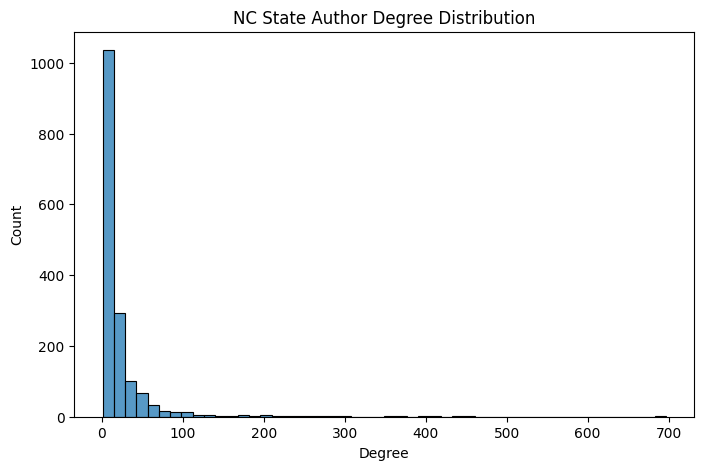

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(nc_metrics_df['degree'], bins=50)
plt.title("NC State Author Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

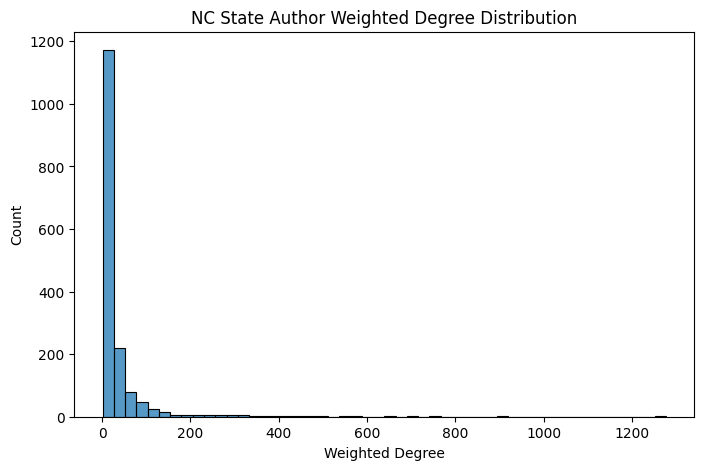

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(nc_metrics_df['weightedDegree'], bins=50)
plt.title("NC State Author Weighted Degree Distribution")
plt.xlabel("Weighted Degree")
plt.ylabel("Count")
plt.show()

## Centrality Distributions

Normalize the larger-scale metrics where helpful and visualize how influence and reach are distributed.


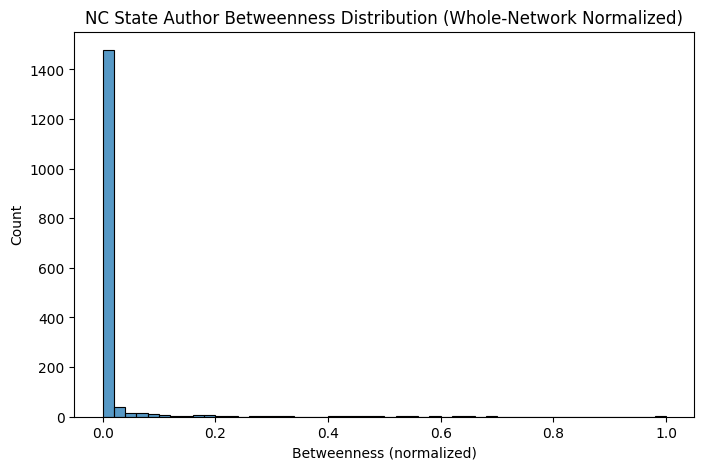

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(nc_metrics_df['betweenness_norm'], bins=50)
plt.title("NC State Author Betweenness Distribution (Whole-Network Normalized)")
plt.xlabel("Betweenness (normalized)")
plt.show()

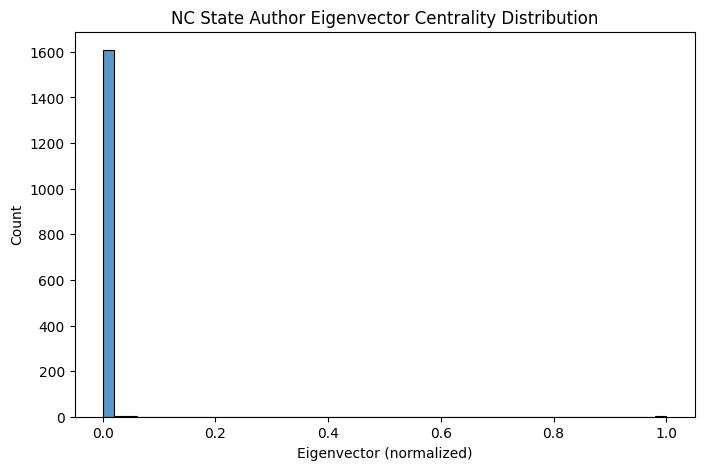

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(nc_metrics_df['eigenvector_norm'], bins=50)
plt.title("NC State Author Eigenvector Centrality Distribution")
plt.xlabel("Eigenvector (normalized)")
plt.show()

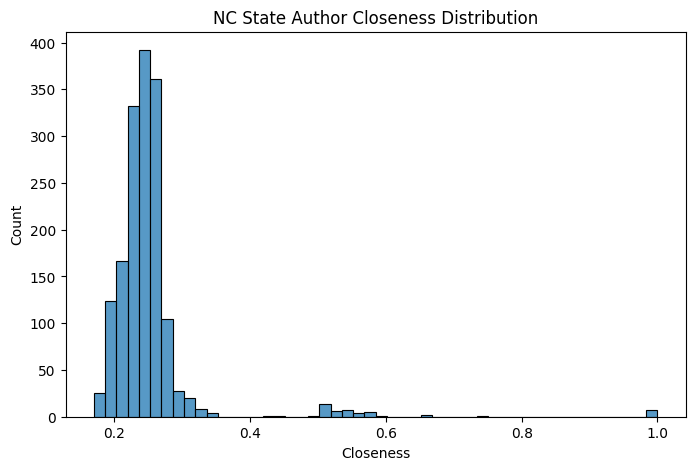

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(nc_metrics_df['closeness'], bins=50)
plt.title("NC State Author Closeness Distribution")
plt.xlabel("Closeness")
plt.show()

## Top-Ranked Authors

These tables surface the highest-scoring NC State authors for several centrality measures. Together they highlight broad collaborators, repeated collaborators, bridge-builders, and authors embedded in influential collaboration cores.


In [13]:
top_degree = nc_metrics_df.sort_values('degree', ascending=False).head(15)
top_degree[['Name','degree']]

,Name,degree
0,"Jones, Jacob",697.0
1,"Holland, James",457.0
7,"Huseth, Anders",446.0
3,"Yencho, Craig",412.0
6,"Thakur, Siddhartha",401.0
2,"Brown-Guedira, Gina",394.0
8,"Barrangou, Rodolphe",367.0
10,"Sozzani, Ross",360.0
17,"Sihi, Debjani",296.0
14,"Wei, Qingshan",283.0


In [14]:
top_weighted = nc_metrics_df.sort_values('weightedDegree', ascending=False).head(15)
top_weighted[['Name', 'weightedDegree', 'degree']]


,Name,weightedDegree,degree
0,"Jones, Jacob",1278.0,697.0
1,"Holland, James",916.0,457.0
2,"Brown-Guedira, Gina",760.0,394.0
3,"Yencho, Craig",709.0,412.0
4,"Theis, Thomas",696.0,225.0
5,"Jordan, David",651.0,266.0
6,"Thakur, Siddhartha",572.0,401.0
7,"Huseth, Anders",570.0,446.0
8,"Barrangou, Rodolphe",551.0,367.0
9,"Daniele, Michael",511.0,278.0


In [15]:
top_betweenness = nc_metrics_df.sort_values('betweenness', ascending=False).head(15)
top_betweenness[['Name', 'betweenness', 'degree']]


,Name,betweenness,degree
0,"Jones, Jacob",5.630925e+06,697.0
3,"Yencho, Craig",3.864975e+06,412.0
7,"Huseth, Anders",3.702949e+06,446.0
8,"Barrangou, Rodolphe",3.540306e+06,367.0
10,"Sozzani, Ross",3.276553e+06,360.0
6,"Thakur, Siddhartha",3.141242e+06,401.0
32,"Nelson, Natalie",3.015118e+06,203.0
35,"Kudenov, Michael",3.014365e+06,157.0
28,"Williams, Cranos",2.815060e+06,198.0
1,"Holland, James",2.613367e+06,457.0


## Metric Relationships

Compare degree and betweenness to see whether broad collaboration also aligns with bridge-like positions in the network.


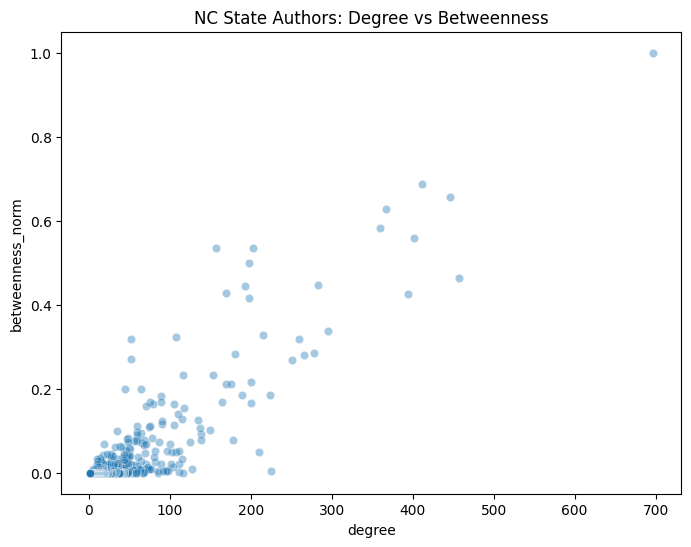

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=nc_metrics_df,
                x='degree',
                y='betweenness_norm',
                alpha=0.4)
plt.title("NC State Authors: Degree vs Betweenness")
plt.show()

## Community Structure

Review how many communities appear in the graph, how large the biggest groups are, and how the NC State slice is distributed across those communities.


In [17]:
pd.Series({
    'distinct_communities_all_authors': int(metrics_df['community'].nunique()),
    'distinct_communities_nc_authors': int(nc_metrics_df['community'].nunique())
})


distinct_communities_all_authors    48
distinct_communities_nc_authors     45
dtype: int64

In [18]:
community_sizes_all = metrics_df['community'].value_counts().rename('all_authors')
community_sizes_nc = nc_metrics_df['community'].value_counts().rename('nc_authors')
community_sizes = pd.concat([community_sizes_all, community_sizes_nc], axis=1).fillna(0).astype(int)
community_sizes.head(10)


,all_authors,nc_authors
community,,
5536,816,333
6713,620,65
3828,469,78
1596,436,42
3633,413,118
1021,385,34
7392,354,44
7050,345,61
2458,331,28


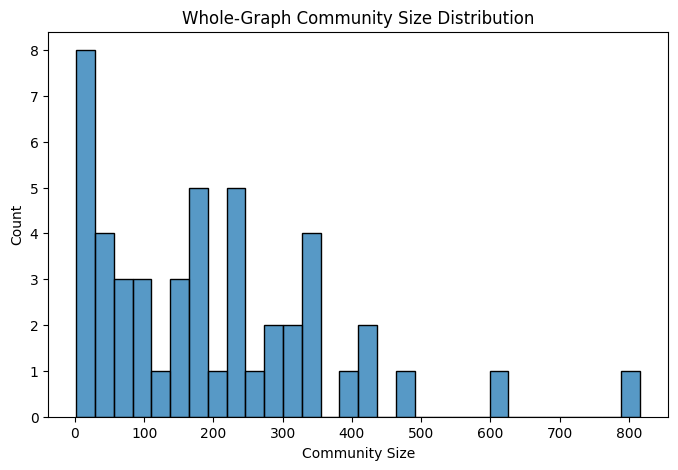

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(community_sizes_all, bins=30)
plt.title("Whole-Graph Community Size Distribution")
plt.xlabel("Community Size")
plt.ylabel("Count")
plt.show()


## Topics By Community

Load the exported `community_topics.csv` file and summarize which topics appear most often inside each author community.


In [20]:
from pathlib import Path

community_topics_path = Path('../data/community_topics.csv')
if not community_topics_path.exists():
    raise FileNotFoundError(
        'Expected ../data/community_topics.csv. Run scripts/export_community_topics.py first.'
    )

community_topics_df = pd.read_csv(community_topics_path)
community_topics_df['community'] = pd.to_numeric(community_topics_df['community'], errors='coerce')
community_topics_df['topic_count'] = pd.to_numeric(community_topics_df['topic_count'], errors='coerce')
community_topics_df['number_of_topics'] = pd.to_numeric(
    community_topics_df['number_of_topics'], errors='coerce'
)
community_topics_df['topic'] = community_topics_df['topic'].astype(str).str.strip()
community_topics_df = community_topics_df[
    community_topics_df['topic'].ne('') &
    community_topics_df['topic'].str.lower().ne('nan')
].copy()
community_topics_df.head()


,community,number_of_topics,topic,topic_count
0,814,68,modeling,458
1,814,68,Ecology,435
2,814,68,conservation,435
3,814,68,sustainable ag,435
4,814,68,community,431


In [21]:
community_topic_summary = (
    community_topics_df
    .sort_values(['community', 'topic_count', 'topic'], ascending=[True, False, True])
    .groupby('community', as_index=False)
    .agg(
        number_of_topics=('number_of_topics', 'max'),
        top_topic=('topic', 'first'),
        top_topic_count=('topic_count', 'first')
    )
    .sort_values(['top_topic_count', 'number_of_topics'], ascending=[False, False])
)

top_topics_per_community = (
    community_topics_df
    .sort_values(['community', 'topic_count', 'topic'], ascending=[True, False, True])
    .groupby('community', group_keys=False)
    .head(5)
    .copy()
)

community_topic_summary.head(15)

,community,number_of_topics,top_topic,top_topic_count
24,5536,68,regenerative ag,2005
31,6713,67,science communication,1219
8,1596,68,genomics,943
21,3828,68,soil,866
20,3633,68,soil,865
34,7114,68,genomics,799
17,2876,67,imaging,719
12,2458,67,breeding,660
35,7375,67,CRISPR,627
3,1021,68,genomics,620


In [22]:
top_topics_per_community[['community', 'topic', 'topic_count']].head(30)


,community,topic,topic_count
0,814,modeling,458
1,814,Ecology,435
2,814,conservation,435
3,814,sustainable ag,435
4,814,community,431
68,853,Ecology,76
69,853,Genetics,76
70,853,conservation,76
71,853,fungi,76
72,853,genomics,76


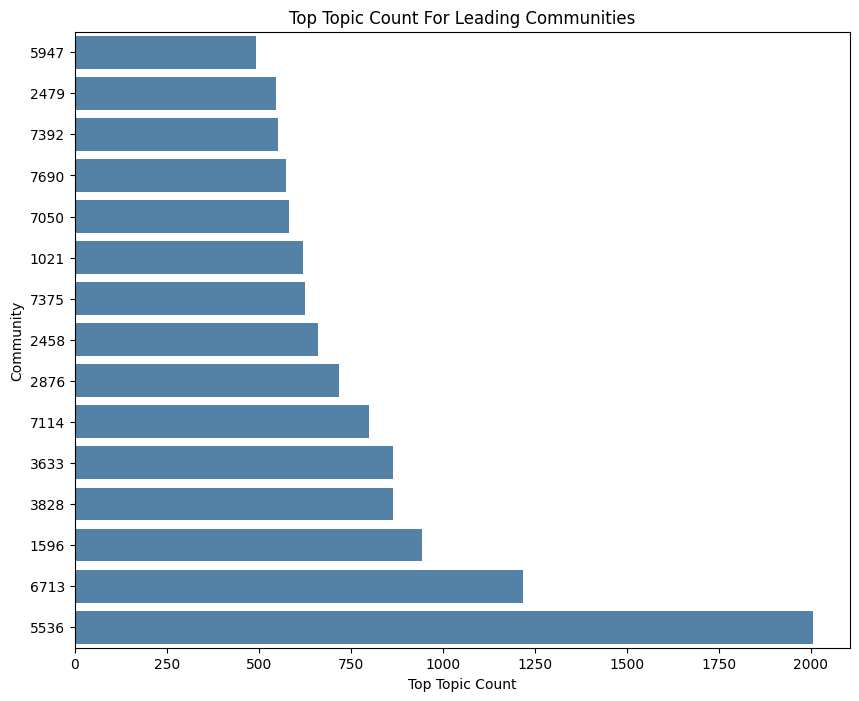

In [23]:
plot_df = community_topic_summary.head(15).sort_values('top_topic_count', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x='top_topic_count', y=plot_df['community'].astype(str), color='steelblue')
plt.title('Top Topic Count For Leading Communities')
plt.xlabel('Top Topic Count')
plt.ylabel('Community')
plt.show()

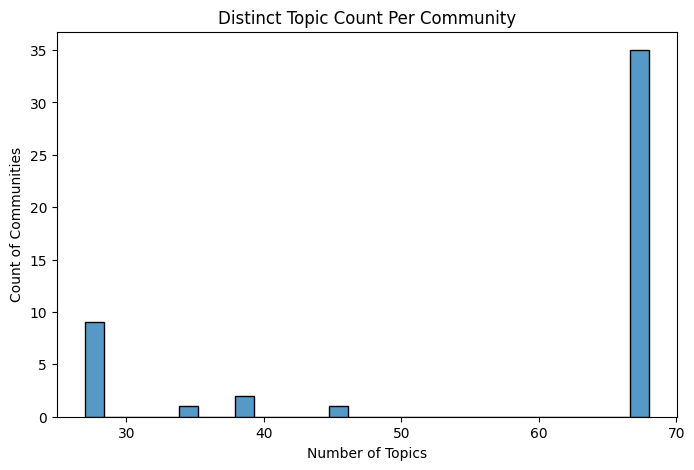

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(community_topic_summary['number_of_topics'], bins=30)
plt.title('Distinct Topic Count Per Community')
plt.xlabel('Number of Topics')
plt.ylabel('Count of Communities')
plt.show()


## Conclusions

The cells below turn the current exports into plain-language summary tables that can be reused in documentation or reports.


In [25]:
centrality_conclusions = pd.DataFrame([
    {
        'finding': 'Whole graph size',
        'conclusion': f"The current centrality export contains {len(metrics_df):,} authors in total, including {len(nc_metrics_df):,} NC State authors and {len(non_nc_metrics_df):,} external collaborators."
    },
    {
        'finding': 'Community structure',
        'conclusion': f"The whole graph spans {metrics_df['community'].nunique():,} detected communities, while NC State authors appear across {nc_metrics_df['community'].nunique():,} communities."
    },
    {
        'finding': 'Collaboration breadth',
        'conclusion': f"Among NC State authors, the median degree is {nc_metrics_df['degree'].median():.0f} and the median weighted degree is {nc_metrics_df['weightedDegree'].median():.0f}, indicating a right-skewed network with a small set of very highly connected researchers."
    },
    {
        'finding': 'Top collaborator by breadth and intensity',
        'conclusion': f"Jacob Jones currently leads NC State authors in both degree ({nc_metrics_df.loc[nc_metrics_df['degree'].idxmax(), 'degree']:.0f}) and weighted degree ({nc_metrics_df.loc[nc_metrics_df['weightedDegree'].idxmax(), 'weightedDegree']:.0f})."
    },
    {
        'finding': 'Bridge-building authors',
        'conclusion': f"Betweenness centrality is led by {nc_metrics_df.loc[nc_metrics_df['betweenness'].idxmax(), 'Name']}, followed by other high-bridge authors such as {', '.join(nc_metrics_df.nlargest(5, 'betweenness')['Name'].tolist()[1:4])}."
    },
    {
        'finding': 'Influential collaboration core',
        'conclusion': f"Eigenvector centrality is dominated by {nc_metrics_df.loc[nc_metrics_df['eigenvector'].idxmax(), 'Name']}, suggesting a particularly strong position inside an influential collaboration cluster rather than only broad degree."
    },
    {
        'finding': 'Metric relationships',
        'conclusion': f"Degree and weighted degree are strongly aligned for NC State authors (correlation {nc_metrics_df[['degree', 'weightedDegree']].corr().iloc[0,1]:.3f}), and degree also tracks strongly with betweenness ({nc_metrics_df[['degree', 'betweenness']].corr().iloc[0,1]:.3f})."
    },
    {
        'finding': 'Closeness caution',
        'conclusion': 'Several NC State authors have closeness values of 1.0, which should be interpreted carefully because closeness can become inflated in very small or tightly bounded components.'
    },
])
centrality_conclusions


,finding,conclusion
0,Whole graph size,"The current centrality export contains 9,575 a..."
1,Community structure,"The whole graph spans 48 detected communities,..."
2,Collaboration breadth,"Among NC State authors, the median degree is 1..."
3,Top collaborator by breadth and intensity,Jacob Jones currently leads NC State authors i...
4,Bridge-building authors,"Betweenness centrality is led by Jones, Jacob,..."
5,Influential collaboration core,"Eigenvector centrality is dominated by Huseth,..."
6,Metric relationships,Degree and weighted degree are strongly aligne...
7,Closeness caution,Several NC State authors have closeness values...


In [26]:
top_overall_topics = (
    community_topics_df
    .groupby('topic', as_index=False)['topic_count']
    .sum()
    .sort_values('topic_count', ascending=False)
)

community_conclusions = pd.DataFrame([
    {
        'finding': 'Community-topic coverage',
        'conclusion': f"The current community-topic export contains {len(community_topics_df):,} community-topic rows across {community_topics_df['community'].nunique():,} communities."
    },
    {
        'finding': 'Topic diversity inside communities',
        'conclusion': f"Communities are generally topic-rich: the median community contains {community_topic_summary['number_of_topics'].median():.0f} distinct topics, with a range from {community_topic_summary['number_of_topics'].min():.0f} to {community_topic_summary['number_of_topics'].max():.0f}."
    },
    {
        'finding': 'Largest topical concentration',
        'conclusion': f"Community {int(community_topic_summary.iloc[0]['community'])} has the strongest single-topic concentration in the export, where '{community_topic_summary.iloc[0]['top_topic']}' appears {int(community_topic_summary.iloc[0]['top_topic_count']):,} times."
    },
    {
        'finding': 'Most frequent topics overall',
        'conclusion': f"Across all communities, the most frequent topics are {', '.join(top_overall_topics.head(5)['topic'].tolist())}."
    },
    {
        'finding': 'Interpretation',
        'conclusion': 'The current topic output suggests that most communities are not narrow single-topic groups. Instead, many communities mix dozens of topics, which is consistent with the project goal of studying interdisciplinary collaboration rather than isolated silos.'
    },
])
community_conclusions


,finding,conclusion
0,Community-topic coverage,"The current community-topic export contains 2,..."
1,Topic diversity inside communities,Communities are generally topic-rich: the medi...
2,Largest topical concentration,Community 5536 has the strongest single-topic ...
3,Most frequent topics overall,"Across all communities, the most frequent topi..."
4,Interpretation,The current topic output suggests that most co...


In [27]:
report_ready_tables = {
    'top_nc_by_degree': nc_metrics_df.nlargest(10, 'degree')[['Name', 'degree', 'weightedDegree', 'community']].reset_index(drop=True),
    'top_nc_by_weighted_degree': nc_metrics_df.nlargest(10, 'weightedDegree')[['Name', 'weightedDegree', 'degree', 'community']].reset_index(drop=True),
    'top_nc_by_betweenness': nc_metrics_df.nlargest(10, 'betweenness')[['Name', 'betweenness', 'degree', 'community']].reset_index(drop=True),
    'top_nc_by_eigenvector': nc_metrics_df.nlargest(10, 'eigenvector')[['Name', 'eigenvector', 'degree', 'community']].reset_index(drop=True),
    'top_communities_by_nc_size': community_sizes.sort_values('nc_authors', ascending=False).head(10).reset_index().rename(columns={'index': 'community'}),
    'top_topics_overall': top_overall_topics.head(15).reset_index(drop=True),
}

report_ready_tables['top_nc_by_degree']


,Name,degree,weightedDegree,community
0,"Jones, Jacob",697.0,1278.0,6713
1,"Holland, James",457.0,916.0,1596
2,"Huseth, Anders",446.0,570.0,8076
3,"Yencho, Craig",412.0,709.0,2458
4,"Thakur, Siddhartha",401.0,572.0,7690
5,"Brown-Guedira, Gina",394.0,760.0,2210
6,"Barrangou, Rodolphe",367.0,551.0,7375
7,"Sozzani, Ross",360.0,510.0,1021
8,"Sihi, Debjani",296.0,354.0,4173
9,"Wei, Qingshan",283.0,416.0,7050
